# Week 7 — 高级分析与定价工具开发

目标：（1）扩展 SHAP / 敏感性分析；（2）进行波动率 +50% 与利率 +2 个百分点的极端压力测试；（3）搭建定价工具原型；（4）加入带回退机制的实时市场数据模块。

**研究边界：** 当前定价目标仍然是 Week 4 的 Monte Carlo 数值参考价格，而不是真实 CME 市场成交价。因此，ML 层应理解为围绕 BSM benchmark 的实验性修正，而不是独立的市场定价真值。

In [1]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from xgboost import XGBRegressor
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
except ImportError:
    pass

PROJECT_DIR = Path("/content/drive/MyDrive/Chooser Option")
LOCAL_DIR = Path("/mnt/data")

def metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

Mounted at /content/drive


In [2]:
DATA_CANDIDATES = [
    PROJECT_DIR / "week2_feature_dataset.csv",
    PROJECT_DIR / "week2_feature_dataset_pipeline.csv",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Week 2 dataset not found.")

REF_CANDIDATES = [
    PROJECT_DIR / "Week4" / "week4_real_data_validation_results.csv",
    PROJECT_DIR / "week4_real_data_validation_results.csv",
    LOCAL_DIR / "week4_real_data_validation_results.csv",
]
REF_PATH = next((p for p in REF_CANDIDATES if p.exists()), None)
if REF_PATH is None:
    raise FileNotFoundError("Week 4 validation results are required.")

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

reference_df = pd.read_csv(REF_PATH, parse_dates=["Date"])

print("Market:", df.shape)
print("Reference:", reference_df.shape)

Market: (1701, 27)
Reference: (1701, 16)


In [3]:
K, Q, T1, T2 = 150.0, 0.0233, 0.5, 1.0

df["Moneyness"] = df["Close"] / K
df["Log_Moneyness"] = np.log(df["Close"] / K)
df["VIX_Decimal"] = df["VIX"] / 100.0
df["Volatility_Spread"] = df["VIX_Decimal"] - df["Rolling_Vol_20D"]
df["Volatility_Ratio"] = df["VIX_Decimal"] / df["Rolling_Vol_20D"].replace(0, np.nan)
df["Price_Momentum_5D"] = df["Close"].pct_change(5)
df["Price_Momentum_20D"] = df["Close"].pct_change(20)
df["Sentiment_x_Volatility"] = df["Market_Sentiment_Index"] * df["Rolling_Vol_20D"]

FEATURES = list(dict.fromkeys([
    "Close","Moneyness","Log_Moneyness",
    "Daily_Return","Log_Return",
    "Rolling_Vol_5D","Rolling_Vol_20D","Rolling_Vol_60D",
    "VIX","VIX_Return","Volatility_Spread","Volatility_Ratio",
    "Treasury_10Y","Rate_Momentum_5D","Rate_Momentum_20D",
    "Rate_Pct_Change_5D","Rate_Pct_Change_20D",
    "VIX_JPM_Correlation_20D",
    "Market_Sentiment_Index","Sentiment_x_Volatility",
    "Price_Momentum_5D","Price_Momentum_20D",
]))
print("Feature count:", len(FEATURES))

Feature count: 22


In [4]:
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
if str(LOCAL_DIR) not in sys.path:
    sys.path.insert(0, str(LOCAL_DIR))

from week3_functions import simple_chooser_option_bsm

pricing_df = df.merge(
    reference_df[["Date", "Monte_Carlo_Price"]],
    on="Date",
    how="inner",
)

bsm = []

for row in pricing_df.itertuples(index=False):
    result = simple_chooser_option_bsm(
        S0=float(row.Close),
        K=K,
        r=float(row.Treasury_10Y) / 100.0,
        q=Q,
        sigma=max(float(row.Rolling_Vol_60D), 1e-4),
        T1=T1,
        T2=T2,
    )

    bsm.append(
        float(result.loc[0, "Chooser_Price"])
    )

pricing_df["BSM_Analytical_Price"] = bsm

pricing_df["Residual"] = (
    pricing_df["Monte_Carlo_Price"]
    - pricing_df["BSM_Analytical_Price"]
)

pricing_df["Relative_Residual"] = (
    pricing_df["Residual"]
    / pricing_df["BSM_Analytical_Price"].replace(0, np.nan)
)

MODEL_FEATURES = list(dict.fromkeys(
    FEATURES + ["BSM_Analytical_Price"]
))

TARGET_COLUMNS = [
    "Monte_Carlo_Price",
    "Residual",
    "Relative_Residual",
]

# Important:
# BSM_Analytical_Price is already included in MODEL_FEATURES,
# so do not append it again here.
MODEL_COLUMNS = list(dict.fromkeys(
    ["Date"]
    + MODEL_FEATURES
    + TARGET_COLUMNS
))

model_df = (
    pricing_df[MODEL_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

# Defensive duplicate-column validation.
duplicate_columns = (
    model_df.columns[
        model_df.columns.duplicated()
    ].tolist()
)

print("Duplicate columns:", duplicate_columns)

if duplicate_columns:
    raise ValueError(
        f"Duplicate columns remain: {duplicate_columns}"
    )

print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

display(model_df.head())

Duplicate columns: []
Rows: 1681
Columns: 27


,Date,Close,Moneyness,Log_Moneyness,Daily_Return,Log_Return,Rolling_Vol_5D,Rolling_Vol_20D,Rolling_Vol_60D,VIX,...,Rate_Pct_Change_20D,VIX_JPM_Correlation_20D,Market_Sentiment_Index,Sentiment_x_Volatility,Price_Momentum_5D,Price_Momentum_20D,BSM_Analytical_Price,Monte_Carlo_Price,Residual,Relative_Residual
0,2018-04-26,110.099998,0.734000,-0.309246,0.001000,0.000999,0.038503,0.248226,0.230626,16.24,...,0.083032,-0.544566,0.903590,0.224294,-0.014501,0.019444,39.978543,39.553431,-0.425112,-0.010634
1,2018-04-27,109.400002,0.729333,-0.315624,-0.006358,-0.006378,0.044613,0.241275,0.231116,15.41,...,0.080292,-0.486355,0.914876,0.220737,-0.018570,-0.005183,40.633907,40.489422,-0.144485,-0.003556
2,2018-04-30,108.779999,0.725200,-0.321308,-0.005667,-0.005683,0.046261,0.231285,0.230836,15.93,...,0.080586,-0.411952,0.907805,0.209962,-0.019382,0.008623,41.166784,40.359905,-0.806879,-0.019600
3,2018-05-01,108.779999,0.725200,-0.321308,0.000000,0.000000,0.052806,0.226169,0.225538,15.49,...,0.064516,-0.371508,0.913788,0.206671,-0.014763,-0.005031,41.011280,40.871047,-0.140233,-0.003419
4,2018-05-02,107.919998,0.719467,-0.329245,-0.007906,-0.007937,0.063887,0.220512,0.226334,15.97,...,0.064516,-0.363127,0.907261,0.200062,-0.018820,-0.027660,41.774512,40.840331,-0.934182,-0.022362


In [ ]:
n = len(model_df)
train_end = int(n*0.70)
val_end = int(n*0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

display(pd.DataFrame({
    "Split":["Train","Validation","Test"],
    "Rows":[len(train_df),len(val_df),len(test_df)],
    "Start":[train_df.Date.min(),val_df.Date.min(),test_df.Date.min()],
    "End":[train_df.Date.max(),val_df.Date.max(),test_df.Date.max()],
}))

X_train, X_val, X_test = [x[MODEL_FEATURES] for x in (train_df,val_df,test_df)]
y_train_resid, y_val_resid = train_df["Residual"], val_df["Residual"]
y_train_rel, y_val_rel = train_df["Relative_Residual"], val_df["Relative_Residual"]

y_val_price = val_df["Monte_Carlo_Price"].to_numpy()
y_test_price = test_df["Monte_Carlo_Price"].to_numpy()
bsm_val = val_df["BSM_Analytical_Price"].to_numpy()
bsm_test = test_df["BSM_Analytical_Price"].to_numpy()

# Keep the Week 2 sentiment definition fixed to the training-period VIX scale.
# This avoids redefining the feature scale every time live data are refreshed.
VIX_SENTIMENT_MIN = float(train_df["VIX"].min())
VIX_SENTIMENT_MAX = float(train_df["VIX"].max())

def vix_to_sentiment(vix_value):
    """Week 2 definition: higher VIX -> lower Market_Sentiment_Index."""
    if np.isclose(VIX_SENTIMENT_MAX, VIX_SENTIMENT_MIN):
        return 0.5
    score = 1.0 - (
        (float(vix_value) - VIX_SENTIMENT_MIN)
        / (VIX_SENTIMENT_MAX - VIX_SENTIMENT_MIN)
    )
    return float(np.clip(score, 0.0, 1.0))

print(
    "Fixed VIX sentiment bounds from training data:",
    round(VIX_SENTIMENT_MIN, 4),
    "to",
    round(VIX_SENTIMENT_MAX, 4),
)


## 1.1 重新拟合 Week 6 选定的 Residual XGBoost

Week 7 不使用 Frozen Test Set 重新调参，而是直接沿用 Week 6 已选定的超参数以及 λ = 0.95。

In [6]:
BEST_XGB_PARAMS = {
    "subsample":0.60, "reg_lambda":5, "reg_alpha":0.1,
    "n_estimators":700, "min_child_weight":12, "max_depth":2,
    "learning_rate":0.01, "colsample_bytree":0.70,
}
BEST_LAMBDA = 0.95
residual_xgb = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1, **BEST_XGB_PARAMS)
trainval_df = pd.concat([train_df,val_df],axis=0)
residual_xgb.fit(trainval_df[MODEL_FEATURES], trainval_df["Residual"])

bsm_test = test_df["BSM_Analytical_Price"].to_numpy()
y_test = test_df["Monte_Carlo_Price"].to_numpy()
ml_test = bsm_test + BEST_LAMBDA*residual_xgb.predict(test_df[MODEL_FEATURES])
display(pd.DataFrame([
    metrics(y_test,bsm_test,"BSM Baseline"),
    metrics(y_test,ml_test,"Static Residual XGB λ=0.95")
]))

WEEK7_DIR = PROJECT_DIR / "Week7"
WEEK7_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(residual_xgb, WEEK7_DIR / "week7_residual_xgb.pkl")


,Model,MAE,RMSE,R2
0,BSM Baseline,0.349716,0.449818,0.999523
1,Static Residual XGB λ=0.95,0.389886,0.506971,0.999394


['/content/drive/MyDrive/Chooser Option/Week7/week7_residual_xgb.pkl']

### 1.1 结果评价

Week 7 重新拟合后的 Static Residual XGBoost 在 Frozen Test 上得到：

- **BSM Baseline：MAE = 0.3497，RMSE = 0.4498，R² = 0.99952**
- **Residual XGBoost（λ = 0.95）：MAE = 0.3899，RMSE = 0.5070，R² = 0.99939**

这与 Week 6 Expanding 的结果基本一致，说明 Week 7 成功复现了原来的实验环境。更重要的是，Residual XGBoost 的 Test RMSE 仍比 BSM 高约 **12.7%**，因此 Week 7 不把这个模型描述成“更准确的定价模型”，而是把它作为一个 **experimental correction layer** 来研究其敏感性和压力环境下的行为。

# 2. 扩展敏感性分析

## 2.1 SHAP 全局特征影响

,Feature,Mean_Abs_SHAP
0,BSM_Analytical_Price,0.110752
1,Close,0.091960
2,Moneyness,0.034302
3,Rolling_Vol_60D,0.014110
4,Volatility_Spread,0.008115
5,Log_Moneyness,0.008018
6,Volatility_Ratio,0.006798
7,Daily_Return,0.005972
8,Rate_Pct_Change_5D,0.004469
9,Price_Momentum_5D,0.004409


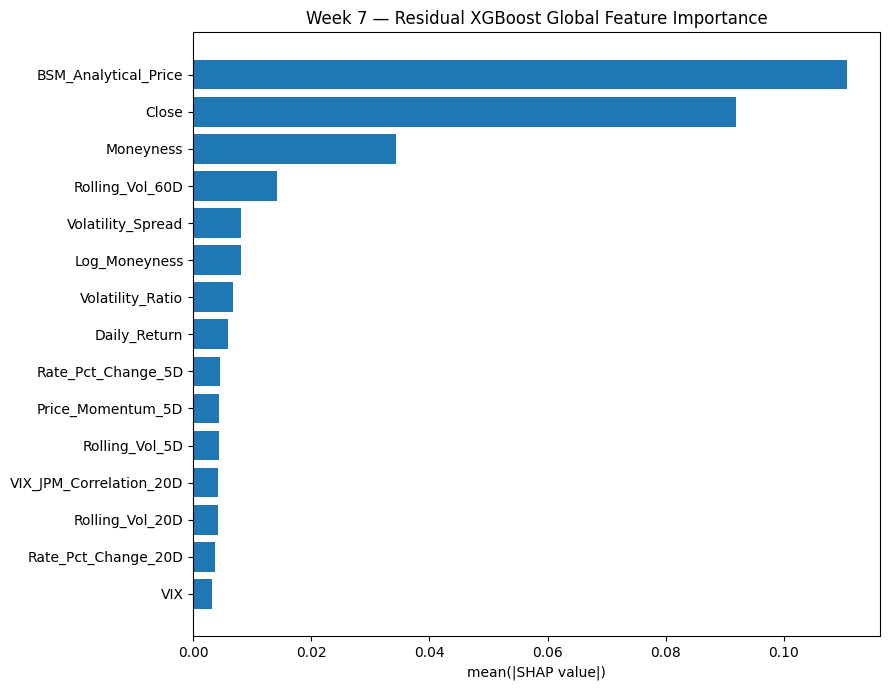

In [7]:
import shap
explainer = shap.TreeExplainer(residual_xgb)
X_shap = test_df[MODEL_FEATURES].copy()
shap_values = explainer.shap_values(X_shap)
shap_importance = pd.DataFrame({
    "Feature":MODEL_FEATURES,
    "Mean_Abs_SHAP":np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP",ascending=False).reset_index(drop=True)
display(shap_importance.head(15))

plt.figure(figsize=(9,7))
p = shap_importance.head(15).sort_values("Mean_Abs_SHAP")
plt.barh(p.Feature,p.Mean_Abs_SHAP)
plt.xlabel("mean(|SHAP value|)")
plt.title("Week 7 — Residual XGBoost Global Feature Importance")
plt.tight_layout(); plt.show()


### 2.1 结果解释与评价

SHAP 的全局结果非常集中：

- `BSM_Analytical_Price`：**0.1108**
- `Close`：**0.0920**
- `Moneyness`：**0.0343**
- `Rolling_Vol_60D`：**0.0141**
- `Volatility_Spread`：**0.0081**
- `VIX` 只有约 **0.0032**

因此当前 Residual XGBoost 主要依赖 **价格水平 / BSM 基础价格 / moneyness** 来决定修正幅度，而不是主要依赖 VIX 或 Sentiment。`BSM_Analytical_Price` 排第一也不能解释成“它是最重要的市场风险因子”，因为 Residual 本身定义为 `Monte Carlo - BSM`，它与 BSM price 存在一定机械价格尺度关系。

这个结果说明：当前 ML correction 更像是在学习“不同价格区间下 BSM residual 的典型大小”，而不是已经学到了一个强而稳定的独立市场风险结构。

## 2.2 关键市场变量的方向性 SHAP 分析

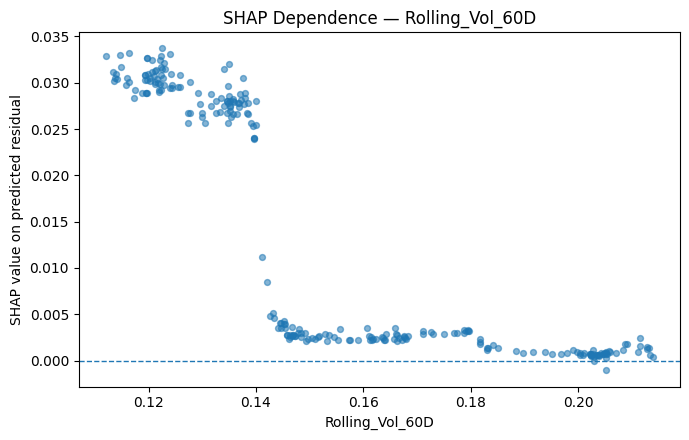

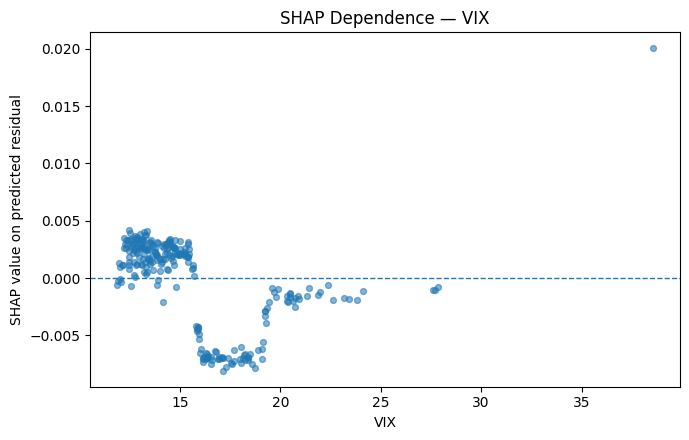

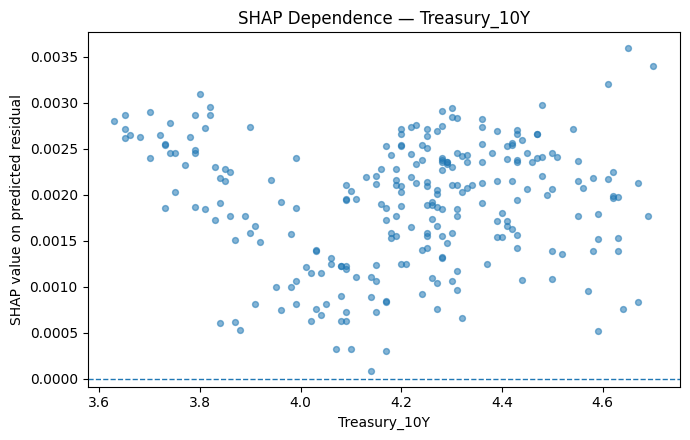

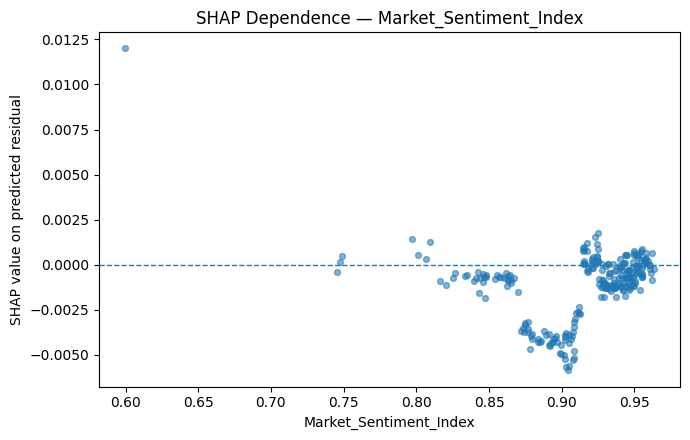

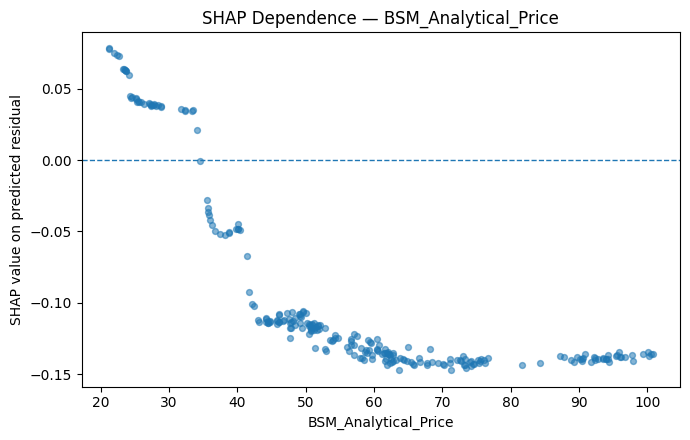

In [8]:
KEY = [f for f in ["Rolling_Vol_60D","VIX","Treasury_10Y","Market_Sentiment_Index","BSM_Analytical_Price"] if f in MODEL_FEATURES]
for feature in KEY:
    j=MODEL_FEATURES.index(feature)
    plt.figure(figsize=(7,4.5))
    plt.scatter(X_shap[feature],shap_values[:,j],alpha=.55,s=18)
    plt.axhline(0,linestyle="--",linewidth=1)
    plt.xlabel(feature); plt.ylabel("SHAP value on predicted residual")
    plt.title(f"SHAP Dependence — {feature}")
    plt.tight_layout(); plt.show()


### 2.2 看什么

重点看 SHAP 是否存在稳定方向，而不是只看点多不多：

- `BSM_Analytical_Price / Close / Moneyness` 若影响最强，说明模型仍主要按价格状态修正 BSM；
- `VIX / Market_Sentiment_Index` 若 SHAP 大多接近 0，说明它们对当前 residual correction 的独立贡献较弱；
- SHAP 正负只表示“把预测 residual 推高或压低”，不代表因果关系。

## 2.3 可控压力情景引擎

In [9]:
def bsm_price_one(S0,K,r_decimal,q,sigma,T1,T2):
    z=simple_chooser_option_bsm(S0=float(S0),K=float(K),r=float(r_decimal),q=float(q),sigma=max(float(sigma),1e-4),T1=float(T1),T2=float(T2))
    return float(z.loc[0,"Chooser_Price"])

def recompute_dependent_features(x,strike=K):
    x=x.copy()
    x["Moneyness"]=x["Close"]/strike
    x["Log_Moneyness"]=np.log(x["Close"]/strike)
    x["VIX_Decimal"]=x["VIX"]/100.0
    x["Volatility_Spread"]=x["VIX_Decimal"]-x["Rolling_Vol_20D"]
    x["Volatility_Ratio"]=x["VIX_Decimal"]/x["Rolling_Vol_20D"].replace(0,np.nan)
    x["Sentiment_x_Volatility"]=x["Market_Sentiment_Index"]*x["Rolling_Vol_20D"]
    return x

def reprice_bsm(frame):
    return np.array([bsm_price_one(r.Close,K,r.Treasury_10Y/100,Q,r.Rolling_Vol_60D,T1,T2) for r in frame.itertuples(index=False)])

base_frame=test_df.copy()
base_bsm=reprice_bsm(base_frame)
base_frame["BSM_Analytical_Price"]=base_bsm
base_ml=base_bsm+BEST_LAMBDA*residual_xgb.predict(base_frame[MODEL_FEATURES])

def run_stress(name,vol_mult=1.0,rate_add_pp=0.0,vix_mult=None,sentiment_shift_sd=0.0):
    x=base_frame.copy()
    for c in ["Rolling_Vol_5D","Rolling_Vol_20D","Rolling_Vol_60D"]: x[c]*=vol_mult
    x["VIX"]*= (vol_mult if vix_mult is None else vix_mult)
    x["Treasury_10Y"] += rate_add_pp
    if sentiment_shift_sd:
        x["Market_Sentiment_Index"] += sentiment_shift_sd*trainval_df["Market_Sentiment_Index"].std()
    x=recompute_dependent_features(x)
    sb=reprice_bsm(x); x["BSM_Analytical_Price"]=sb
    sm=sb+BEST_LAMBDA*residual_xgb.predict(x[MODEL_FEATURES])
    return {"Scenario":name,"BSM_Mean":sb.mean(),"ML_Adjusted_Mean":sm.mean(),"Mean_ML_Correction":(sm-sb).mean(),"BSM_Change_vs_Base":sb.mean()-base_bsm.mean(),"ML_Change_vs_Base":sm.mean()-base_ml.mean()},sb,sm


## 2.4 极端情景测试 — 波动率 +50% / 利率 +2 个百分点

,Scenario,BSM_Mean,ML_Adjusted_Mean,Mean_ML_Correction,BSM_Change_vs_Base,ML_Change_vs_Base
0,Base,56.6430,56.4055,-0.2375,0.0000,0.0000
1,Volatility +50%,58.5645,58.2917,-0.2727,1.9215,1.8862
2,Rate +2pp,59.3733,59.1292,-0.2440,2.7303,2.7237
3,Vol +50% & Rate +2pp,60.9775,60.7011,-0.2765,4.3345,4.2955


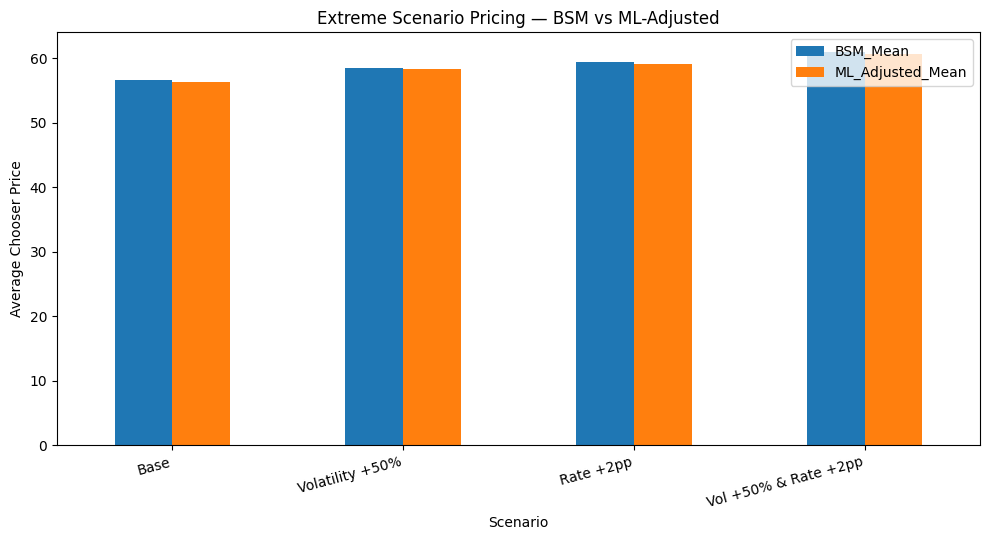

In [10]:
specs=[("Base",1,0),("Volatility +50%",1.5,0),("Rate +2pp",1,2),("Vol +50% & Rate +2pp",1.5,2)]
rows=[]; paths={}
for name,vm,ra in specs:
    row,sb,sm=run_stress(name,vm,ra); rows.append(row); paths[name]=(sb,sm)
scenario_df=pd.DataFrame(rows)
display(scenario_df.round(4))
ax=scenario_df.set_index("Scenario")[["BSM_Mean","ML_Adjusted_Mean"]].plot(kind="bar",figsize=(10,5.5))
ax.set_ylabel("Average Chooser Price"); ax.set_title("Extreme Scenario Pricing — BSM vs ML-Adjusted")
plt.xticks(rotation=15,ha="right"); plt.tight_layout(); plt.show()


### 2.4 极端情景结果解释

压力测试得到的平均价格变化为：

- **Base：BSM = 56.6430，ML-adjusted = 56.4055**
- **Volatility +50%：BSM 上升 1.9215，ML-adjusted 上升 1.8862**
- **Rate +2pp：BSM 上升 2.7303，ML-adjusted 上升 2.7237**
- **Vol +50% & Rate +2pp：BSM 上升 4.3345，ML-adjusted 上升 4.2955**

最重要的观察是：ML-adjusted price 与 BSM 的压力反应非常接近，没有出现“BSM 只变化几美元，而 ML correction 自己跳动很多美元”的情况。

Base 状态下平均 ML correction 为 **-0.2375**；在 Volatility +50% 时为 **-0.2727**，Rate +2pp 时为 **-0.2440**，组合压力时为 **-0.2765**。也就是说，即使在极端冲击下，ML 层仍主要是几毛钱级别的修正，并没有主导整个价格变化。

因此这一组 stress test 的结论是：**当前 Residual XGBoost 在这两个设定的压力方向下没有明显数值失控，但它也没有改变 BSM 对主要风险因素的总体定价结构。**

## 2.5 VIX、市场情绪、波动率与利率敏感性曲线

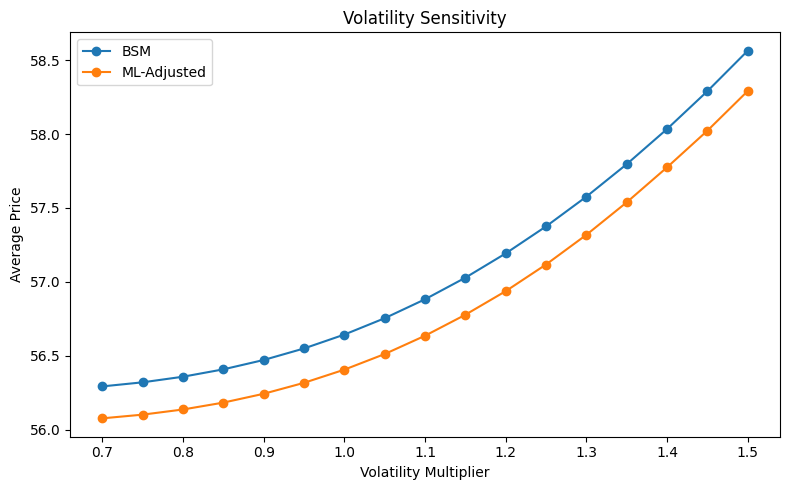

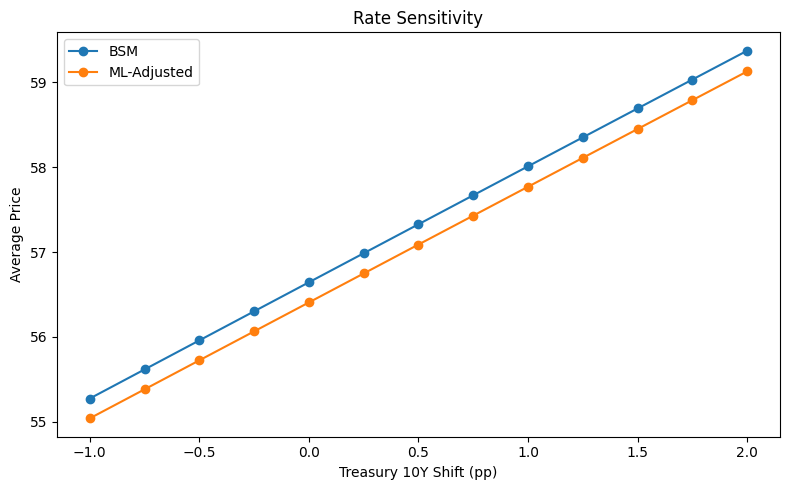

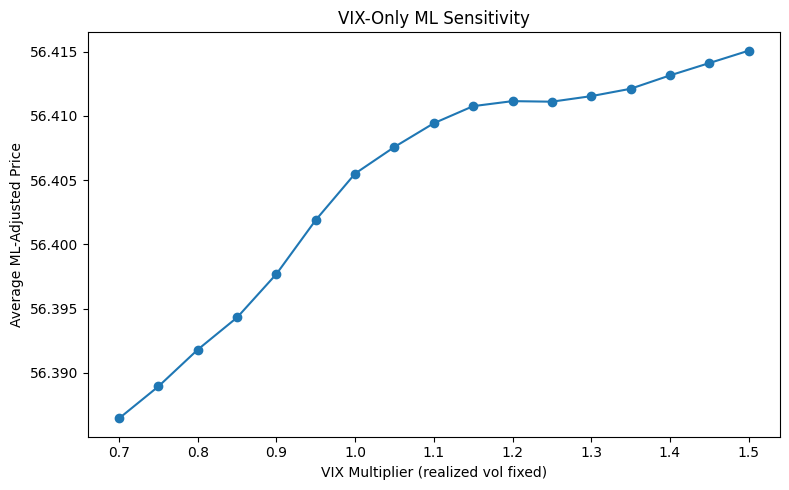

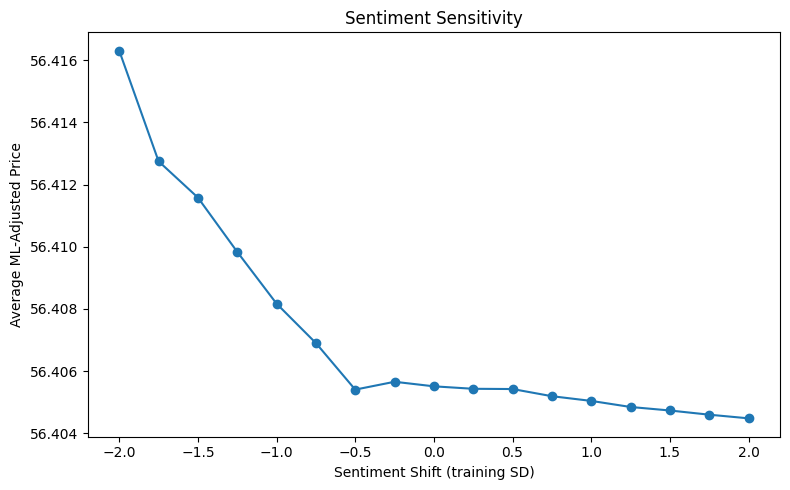

In [11]:
def mean_stress(**kwargs):
    _,sb,sm=run_stress("tmp",**kwargs); return sb.mean(),sm.mean()

vol_grid=np.linspace(.7,1.5,17)
vol_curve=pd.DataFrame([{"Shock":g,"BSM":mean_stress(vol_mult=g)[0],"ML":mean_stress(vol_mult=g)[1]} for g in vol_grid])
plt.figure(figsize=(8,5)); plt.plot(vol_curve.Shock,vol_curve.BSM,marker="o",label="BSM"); plt.plot(vol_curve.Shock,vol_curve.ML,marker="o",label="ML-Adjusted"); plt.xlabel("Volatility Multiplier"); plt.ylabel("Average Price"); plt.title("Volatility Sensitivity"); plt.legend(); plt.tight_layout(); plt.show()

rate_grid=np.linspace(-1,2,13)
rate_curve=pd.DataFrame([{"Shock":g,"BSM":mean_stress(rate_add_pp=g)[0],"ML":mean_stress(rate_add_pp=g)[1]} for g in rate_grid])
plt.figure(figsize=(8,5)); plt.plot(rate_curve.Shock,rate_curve.BSM,marker="o",label="BSM"); plt.plot(rate_curve.Shock,rate_curve.ML,marker="o",label="ML-Adjusted"); plt.xlabel("Treasury 10Y Shift (pp)"); plt.ylabel("Average Price"); plt.title("Rate Sensitivity"); plt.legend(); plt.tight_layout(); plt.show()

vix_grid=np.linspace(.7,1.5,17)
vix_curve=pd.DataFrame([{"Shock":g,"ML":mean_stress(vix_mult=g)[1]} for g in vix_grid])
plt.figure(figsize=(8,5)); plt.plot(vix_curve.Shock,vix_curve.ML,marker="o"); plt.xlabel("VIX Multiplier (realized vol fixed)"); plt.ylabel("Average ML-Adjusted Price"); plt.title("VIX-Only ML Sensitivity"); plt.tight_layout(); plt.show()

sent_grid=np.linspace(-2,2,17)
sent_curve=pd.DataFrame([{"Shock":g,"ML":mean_stress(sentiment_shift_sd=g)[1]} for g in sent_grid])
plt.figure(figsize=(8,5)); plt.plot(sent_curve.Shock,sent_curve.ML,marker="o"); plt.xlabel("Sentiment Shift (training SD)"); plt.ylabel("Average ML-Adjusted Price"); plt.title("Sentiment Sensitivity"); plt.tight_layout(); plt.show()


### 2.5 看什么

- **Volatility / Rate**：比较 BSM 和 ML-adjusted 曲线是否大体平行；如果 ML 曲线突然偏离，说明 correction 在外推。
- **VIX / Sentiment**：主要检查 ML correction 对新增特征是否敏感。由于 sentiment 本身由 VIX 推导，两者不是独立经济变量，不能把它们的影响简单相加。

## 2.6 压力测试稳定性诊断

In [12]:
diag=pd.DataFrame({"Date":test_df.Date.to_numpy(),"Base_BSM":base_bsm,"Base_ML":base_ml,"Base_Correction":base_ml-base_bsm})
for name in ["Volatility +50%","Rate +2pp","Vol +50% & Rate +2pp"]:
    sb,sm=paths[name]; safe=name.replace(" ","_").replace("+","plus").replace("&","and")
    diag[safe+"_Correction_Change"]=(sm-sb)-(base_ml-base_bsm)
display(diag.describe().T.round(4))
scenario_df.to_csv(WEEK7_DIR/"week7_scenario_summary.csv",index=False)
diag.to_csv(WEEK7_DIR/"week7_stress_diagnostics.csv",index=False)


,count,mean,min,25%,50%,75%,max,std
Date,253,2024-06-29 14:59:17.312252928,2023-12-28 00:00:00,2024-04-01 00:00:00,2024-07-01 00:00:00,2024-09-30 00:00:00,2024-12-30 00:00:00,NaN
Base_BSM,253.0,56.642964,21.173249,44.18046,54.283649,68.537762,100.797792,20.677464
Base_ML,253.0,56.40551,21.150967,43.936168,53.986252,68.262135,100.521981,20.619627
Base_Correction,253.0,-0.237454,-0.357609,-0.291979,-0.266334,-0.219144,-0.014783,0.084229
Volatility_plus50%_Correction_Change,253.0,-0.035274,-0.111566,-0.050916,-0.033703,-0.014206,0.037994,0.028704
Rate_plus2pp_Correction_Change,253.0,-0.006593,-0.073729,-0.007185,-0.000715,0.0,0.003852,0.013341
Vol_plus50%_and_Rate_plus2pp_Correction_Change,253.0,-0.038997,-0.111566,-0.056675,-0.037721,-0.015713,0.037994,0.030955


### 2.6 判断标准

如果 stress 后的 `Correction_Change` 仍远小于 BSM 本身的价格变化，说明 ML 没有在压力环境下主导定价；如果 correction 明显放大，则视为外推风险。

# 3. 定价工具框架

In [13]:
def price_chooser_bsm(S,K=K,r=.04,q=Q,sigma=.25,T1=T1,T2=T2):
    return bsm_price_one(S,K,r,q,sigma,T1,T2)

def price_with_ml_adjustment(feature_row,strike=K,model=residual_xgb,lam=BEST_LAMBDA):
    x=pd.DataFrame([feature_row]).copy(); x=recompute_dependent_features(x,strike)
    bsm=bsm_price_one(x.loc[0,"Close"],strike,x.loc[0,"Treasury_10Y"]/100,Q,x.loc[0,"Rolling_Vol_60D"],T1,T2)
    x["BSM_Analytical_Price"]=bsm
    missing=[c for c in MODEL_FEATURES if c not in x.columns]
    if missing: raise ValueError(f"Missing model features: {missing}")
    resid=float(model.predict(x[MODEL_FEATURES])[0]); adjusted=bsm+lam*resid
    return {"BSM_Price":bsm,"Predicted_Residual":resid,"Lambda":lam,"ML_Adjusted_Price":adjusted,"ML_Correction":adjusted-bsm}

example=test_df.iloc[-1].drop(labels=["Date","Monte_Carlo_Price","Residual","Relative_Residual","BSM_Analytical_Price"]).to_dict()
display(pd.DataFrame([price_with_ml_adjustment(example)]))


,BSM_Price,Predicted_Residual,Lambda,ML_Adjusted_Price,ML_Correction
0,90.481149,-0.263277,0.95,90.231036,-0.250114


### 3. 工具输出

工具把价格拆成三部分：

\[
Final\ Price = BSM + \lambda 	imes Predicted\ Residual
\]

因此需要同时展示 BSM、Residual 和最终 correction，而不是只显示一个 ML price。

限制仍是：Residual model 围绕当前项目训练分布建立，尤其是 `K=150`；任意 strike / maturity 的 ML adjustment 不应直接视为可靠报价。

## 3.1 Streamlit 最终定价工具原型

最终版 UI 不再只是一个 BSM Calculator，而是分成两个功能：

1. **Manual BSM Pricing**：允许输入 `S, K, r, q, σ, T1, T2`，用于独立检查解析定价结果；
2. **Latest Market BSM + ML Adjustment**：读取最新市场快照，显示 BSM Price、Predicted Residual、λ、ML-adjusted Price 和 correction。

这样 Week 7 的 Tool Framework 才真正和 Week 6 的 Residual XGBoost 模型连接起来。

> 注意：ML correction 仍然只适用于当前研究训练分布，尤其是项目基准 `K = 150`。如果用户手工改变 strike / maturity，工具只输出 BSM，不把 Residual XGBoost 当作可泛化到任意合约的生产模型。

In [ ]:
# Export a more complete Streamlit prototype.
STREAMLIT_APP = r"""
import streamlit as st
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import joblib

PROJECT_DIR = Path("/content/drive/MyDrive/Chooser Option")
WEEK7_DIR = PROJECT_DIR / "Week7"
sys.path.insert(0, str(PROJECT_DIR))

from week3_functions import simple_chooser_option_bsm

MODEL_PATH = WEEK7_DIR / "week7_residual_xgb.pkl"
SNAPSHOT_PATH = WEEK7_DIR / "latest_model_feature_snapshot.csv"
CONFIG_PATH = WEEK7_DIR / "week7_model_config.json"

st.set_page_config(page_title="Chooser Option Research Pricer", layout="wide")
st.title("Chooser Option Research Pricing Tool")
st.caption("Analytical BSM benchmark + experimental Residual XGBoost correction")

def bsm_price(S, K, r, q, sigma, T1, T2):
    z = simple_chooser_option_bsm(
        S0=float(S), K=float(K), r=float(r), q=float(q),
        sigma=float(sigma), T1=float(T1), T2=float(T2)
    )
    return float(z.loc[0, "Chooser_Price"])

manual_tab, live_tab = st.tabs(["Manual BSM Pricing", "Latest Market BSM + ML"])

with manual_tab:
    st.subheader("Manual BSM Pricing")
    c1, c2, c3 = st.columns(3)
    with c1:
        S = st.number_input("Underlying price (S)", value=150.0, min_value=0.01)
        K = st.number_input("Strike (K)", value=150.0, min_value=0.01)
    with c2:
        r = st.number_input("Risk-free rate (decimal)", value=0.04, step=0.001, format="%.4f")
        q = st.number_input("Dividend yield (decimal)", value=0.0233, step=0.001, format="%.4f")
    with c3:
        sigma = st.number_input("Volatility (decimal)", value=0.25, min_value=0.0001, step=0.01)
        T1 = st.number_input("Choice time T1", value=0.50, min_value=0.001)
        T2 = st.number_input("Maturity T2", value=1.00, min_value=0.002)

    if T1 >= T2:
        st.error("T1 must be smaller than T2.")
    elif st.button("Price Chooser Option", key="manual_price"):
        p = bsm_price(S, K, r, q, sigma, T1, T2)
        st.metric("BSM Analytical Price", f"{p:.4f}")
        if abs(K - 150.0) > 1e-9:
            st.warning("ML correction is not shown because the trained residual model is centered on the project setting K=150.")

with live_tab:
    st.subheader("Latest Market Snapshot + ML Adjustment")
    if not MODEL_PATH.exists() or not SNAPSHOT_PATH.exists() or not CONFIG_PATH.exists():
        st.error("Required Week 7 model/snapshot/config files are missing. Run the Week 7 notebook first.")
    else:
        model = joblib.load(MODEL_PATH)
        snap = pd.read_csv(SNAPSHOT_PATH)
        config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
        features = config["MODEL_FEATURES"]
        lam = float(config["BEST_LAMBDA"])

        missing = [c for c in features if c not in snap.columns]
        if missing:
            st.error(f"Missing model features in latest snapshot: {missing}")
        else:
            residual = float(model.predict(snap[features])[0])
            bsm = float(snap.loc[0, "BSM_Analytical_Price"])
            adjusted = bsm + lam * residual

            m1, m2, m3, m4 = st.columns(4)
            m1.metric("BSM Price", f"{bsm:.4f}")
            m2.metric("Predicted Residual", f"{residual:.4f}")
            m3.metric("ML Correction", f"{lam*residual:.4f}")
            m4.metric("ML-Adjusted Price", f"{adjusted:.4f}")

            show_cols = [c for c in [
                "Timestamp","Close","VIX","Treasury_10Y","Rolling_Vol_20D",
                "Rolling_Vol_60D","Market_Sentiment_Index","Source","Sentiment_Source"
            ] if c in snap.columns]
            st.dataframe(snap[show_cols].T.rename(columns={0:"Value"}))

            st.warning(
                "Research prototype only. The ML layer was trained on the project specification "
                "and did not outperform BSM on the frozen test set. Market_Sentiment_Index is a VIX-derived proxy generated from the latest market snapshot."
            )
"""

app_path = WEEK7_DIR / "week7_streamlit_app_final.py"
app_path.write_text(STREAMLIT_APP, encoding="utf-8")
print("Saved:", app_path)
print("Run with: streamlit run", app_path)


# 4. 实时市场数据整合

In [ ]:
def fetch_live_market_snapshot(local_history=df):
    """
    Fetch current/delayed JPM, VIX and 10Y Treasury data.
    Market_Sentiment_Index is recalculated from the current VIX using
    the fixed Week 2 / training-period VIX normalization.
    """
    try:
        import yfinance as yf

        jpm = yf.download(
            "JPM", period="6mo", interval="1d",
            auto_adjust=True, progress=False
        )
        vix = yf.download(
            "^VIX", period="6mo", interval="1d",
            auto_adjust=True, progress=False
        )
        tnx = yf.download(
            "^TNX", period="6mo", interval="1d",
            auto_adjust=True, progress=False
        )

        if jpm.empty or vix.empty or tnx.empty:
            raise RuntimeError("Empty live series")

        def close_series(frame):
            s = frame["Close"]
            return s.iloc[:, 0] if isinstance(s, pd.DataFrame) else s

        jp = close_series(jpm).dropna()
        vx = close_series(vix).dropna()
        ty = close_series(tnx).dropna()
        ret = jp.pct_change()

        current_vix = float(vx.iloc[-1])

        return {
            "Timestamp": pd.Timestamp.now(),
            "Close": float(jp.iloc[-1]),
            "VIX": current_vix,
            "Treasury_10Y": float(ty.iloc[-1]),
            "Daily_Return": float(ret.iloc[-1]),
            "Log_Return": float(np.log(jp.iloc[-1] / jp.iloc[-2])),
            "Rolling_Vol_5D": float(ret.rolling(5).std().iloc[-1] * np.sqrt(252)),
            "Rolling_Vol_20D": float(ret.rolling(20).std().iloc[-1] * np.sqrt(252)),
            "Rolling_Vol_60D": float(ret.rolling(60).std().iloc[-1] * np.sqrt(252)),
            "Market_Sentiment_Index": vix_to_sentiment(current_vix),
            "Source": "yfinance live/delayed",
            "Sentiment_Source": "VIX-derived in real time using fixed training-period bounds",
        }

    except Exception as e:
        last = local_history.dropna(
            subset=["Close", "VIX", "Treasury_10Y"]
        ).iloc[-1]

        last_vix = float(last["VIX"])

        return {
            "Timestamp": last["Date"],
            "Close": float(last["Close"]),
            "VIX": last_vix,
            "Treasury_10Y": float(last["Treasury_10Y"]),
            "Rolling_Vol_5D": float(last["Rolling_Vol_5D"]),
            "Rolling_Vol_20D": float(last["Rolling_Vol_20D"]),
            "Rolling_Vol_60D": float(last["Rolling_Vol_60D"]),
            "Market_Sentiment_Index": vix_to_sentiment(last_vix),
            "Source": f"local CSV fallback ({type(e).__name__})",
            "Sentiment_Source": "VIX-derived from fallback VIX using fixed training-period bounds",
        }

live_snapshot = fetch_live_market_snapshot()
display(
    pd.DataFrame([live_snapshot])
    .T.rename(columns={0: "Value"})
)

## 4.1 自动更新函数

In [ ]:
def update_market_snapshot(save=True):
    result=pd.DataFrame([fetch_live_market_snapshot()])
    if save: result.to_csv(WEEK7_DIR/"latest_market_snapshot.csv",index=False)
    return result
latest_market=update_market_snapshot(); display(latest_market)


## 4.2 将实时数据真正接入定价模型

前面的 `fetch_live_market_snapshot()` 只完成了“取数据”。最终版再补一层 **live feature engineering**，把 JPM、VIX、10Y Treasury 等实时/延迟行情转成 Residual XGBoost 所需的完整特征向量，然后直接得到：

\[
Live\ Data ightarrow Feature\ Engineering ightarrow BSM ightarrow Residual\ XGBoost ightarrow ML	ext{-}Adjusted\ Price
\]

这一步把 Week 7 的三个模块真正串在一起。

其中：
- 可以由 live history 计算的特征（returns、rolling vol、VIX return、rate momentum、correlation）全部重新计算；
- `Market_Sentiment_Index` 仍使用最近本地存储值，并明确标记来源；
- 不能安全实时更新的变量不会伪造，而是保留最近历史值并记录 fallback。

In [ ]:
def build_live_model_feature_snapshot(local_history=df):
    """
    Build a complete model feature row using live/delayed public market data where possible.
    Any feature that cannot be recreated safely is taken from the latest historical row
    and explicitly treated as a fallback.
    """
    try:
        import yfinance as yf

        jpm = yf.download("JPM", period="1y", interval="1d", auto_adjust=True, progress=False)
        vix = yf.download("^VIX", period="1y", interval="1d", auto_adjust=True, progress=False)
        tnx = yf.download("^TNX", period="1y", interval="1d", auto_adjust=True, progress=False)

        if jpm.empty or vix.empty or tnx.empty:
            raise RuntimeError("One or more live series are empty.")

        def close_series(frame):
            s = frame["Close"]
            return s.iloc[:, 0] if isinstance(s, pd.DataFrame) else s

        jp = close_series(jpm).dropna()
        vx = close_series(vix).dropna()
        ty = close_series(tnx).dropna()

        aligned = pd.concat(
            [jp.rename("Close"), vx.rename("VIX"), ty.rename("Treasury_10Y")],
            axis=1
        ).dropna()

        aligned["Daily_Return"] = aligned["Close"].pct_change()
        aligned["Log_Return"] = np.log(aligned["Close"] / aligned["Close"].shift(1))
        aligned["VIX_Return"] = aligned["VIX"].pct_change()

        for w in [5, 20, 60]:
            aligned[f"Rolling_Vol_{w}D"] = aligned["Daily_Return"].rolling(w).std() * np.sqrt(252)

        aligned["Rate_Momentum_5D"] = aligned["Treasury_10Y"] - aligned["Treasury_10Y"].shift(5)
        aligned["Rate_Momentum_20D"] = aligned["Treasury_10Y"] - aligned["Treasury_10Y"].shift(20)
        aligned["Rate_Pct_Change_5D"] = aligned["Treasury_10Y"].pct_change(5)
        aligned["Rate_Pct_Change_20D"] = aligned["Treasury_10Y"].pct_change(20)
        aligned["Price_Momentum_5D"] = aligned["Close"].pct_change(5)
        aligned["Price_Momentum_20D"] = aligned["Close"].pct_change(20)
        aligned["VIX_JPM_Correlation_20D"] = (
            aligned["VIX_Return"].rolling(20).corr(aligned["Daily_Return"])
        )

        live = aligned.dropna().iloc[-1].to_dict()
        live["Timestamp"] = aligned.dropna().index[-1]
        live["Source"] = "yfinance live/delayed market data"

    except Exception as e:
        last = local_history.dropna().iloc[-1]
        live = {c: last[c] for c in last.index if c != "Date"}
        live["Timestamp"] = last["Date"]
        live["Source"] = f"local CSV fallback ({type(e).__name__})"

    # Recalculate sentiment from the current VIX using the same Week 2 definition.
    live["Market_Sentiment_Index"] = vix_to_sentiment(float(live["VIX"]))
    live["Sentiment_Source"] = "VIX-derived using fixed training-period bounds"

    # Rebuild features that are mechanically determined by current market state.
    live["Moneyness"] = float(live["Close"]) / K
    live["Log_Moneyness"] = np.log(float(live["Close"]) / K)
    live["VIX_Decimal"] = float(live["VIX"]) / 100.0
    live["Volatility_Spread"] = live["VIX_Decimal"] - float(live["Rolling_Vol_20D"])
    live["Volatility_Ratio"] = (
        live["VIX_Decimal"] / max(float(live["Rolling_Vol_20D"]), 1e-8)
    )
    live["Sentiment_x_Volatility"] = (
        float(live["Market_Sentiment_Index"]) * float(live["Rolling_Vol_20D"])
    )

    # If any model feature is still unavailable, use the latest historical value
    # rather than inventing a live observation.
    latest_hist = local_history.dropna().iloc[-1]
    fallback_features = []
    for feature in MODEL_FEATURES:
        if feature == "BSM_Analytical_Price":
            continue
        if feature not in live or pd.isna(live[feature]):
            if feature in latest_hist.index and pd.notna(latest_hist[feature]):
                live[feature] = float(latest_hist[feature])
                fallback_features.append(feature)

    # Recalculate BSM price using the live state.
    live["BSM_Analytical_Price"] = bsm_price_one(
        S0=float(live["Close"]),
        K=K,
        r_decimal=float(live["Treasury_10Y"]) / 100.0,
        q=Q,
        sigma=float(live["Rolling_Vol_60D"]),
        T1=T1,
        T2=T2,
    )

    live["Fallback_Features"] = ", ".join(fallback_features) if fallback_features else "None"

    snap = pd.DataFrame([live])
    missing = [c for c in MODEL_FEATURES if c not in snap.columns or snap[c].isna().any()]
    if missing:
        raise ValueError(f"Live model feature snapshot still has missing features: {missing}")

    return snap


latest_model_snapshot = build_live_model_feature_snapshot()

live_residual = float(
    residual_xgb.predict(latest_model_snapshot[MODEL_FEATURES])[0]
)
live_bsm_price = float(latest_model_snapshot.loc[0, "BSM_Analytical_Price"])
live_ml_price = live_bsm_price + BEST_LAMBDA * live_residual

live_pricing_result = pd.DataFrame([{
    "Timestamp": latest_model_snapshot.loc[0, "Timestamp"],
    "BSM_Price": live_bsm_price,
    "Predicted_Residual": live_residual,
    "Lambda": BEST_LAMBDA,
    "ML_Correction": BEST_LAMBDA * live_residual,
    "ML_Adjusted_Price": live_ml_price,
    "Market_Data_Source": latest_model_snapshot.loc[0, "Source"],
    "Sentiment_Source": latest_model_snapshot.loc[0, "Sentiment_Source"],
    "Fallback_Features": latest_model_snapshot.loc[0, "Fallback_Features"],
}])

display(live_pricing_result.T.rename(columns={0: "Value"}))

# Save the complete snapshot for the Streamlit application.
latest_model_snapshot.to_csv(
    WEEK7_DIR / "latest_model_feature_snapshot.csv", index=False
)

import json
config = {
    "MODEL_FEATURES": MODEL_FEATURES,
    "BEST_LAMBDA": BEST_LAMBDA,
    "K": K,
    "Q": Q,
    "T1": T1,
    "T2": T2,
}
(WEEK7_DIR / "week7_model_config.json").write_text(
    json.dumps(config, indent=2), encoding="utf-8"
)

live_pricing_result.to_csv(
    WEEK7_DIR / "latest_live_pricing_result.csv", index=False
)

print("Saved complete live model snapshot and pricing result to Week7 folder.")


### 4.2 检查重点

运行这一节后只检查四件事：

- `Market_Data_Source`：是否成功使用 yfinance；失败时会明确显示 CSV fallback。
- `Sentiment_Source`：应显示 **VIX-derived**，说明 `Market_Sentiment_Index` 已由当前 VIX 自动计算。
- `Fallback_Features`：如果不是 `None`，说明仍有部分模型变量无法由当前行情直接重建。
- 最终必须同时输出 `BSM_Price`、`Predicted_Residual`、`ML_Correction` 和 `ML_Adjusted_Price`。

这里的 ML price 仍是研究输出，因为 Week 6 Frozen Test 中 Residual XGBoost 没有超过 BSM。

### 4. 实时数据结果

当前模块已形成：

`JPM / VIX / 10Y Treasury → rolling features → VIX-derived sentiment → BSM → Residual XGBoost`

其中 `Market_Sentiment_Index` 不再使用上一条历史值，而是按 Week 2 的定义由当前 VIX 自动计算：

\[
Sentiment_t
=
1-rac{VIX_t-VIX_{min,train}}
{VIX_{max,train}-VIX_{min,train}}
\]

并限制在 `[0, 1]`。

这里固定使用 Training Period 的 VIX min/max，避免每次刷新数据都改变 sentiment 的尺度。需要注意：它是 **VIX-derived sentiment proxy**，不是新闻/NLP sentiment。

# 5. Week 7 最终评价

In [17]:
base=scenario_df.iloc[0]; vol=scenario_df.iloc[1]; rate=scenario_df.iloc[2]; combo=scenario_df.iloc[3]
print("WEEK 7 SUMMARY")
print("Top SHAP feature:",shap_importance.iloc[0]["Feature"])
print(f"Base mean BSM={base.BSM_Mean:.4f}; ML-adjusted={base.ML_Adjusted_Mean:.4f}")
print(f"Vol +50%: BSM Δ={vol.BSM_Change_vs_Base:.4f}; ML Δ={vol.ML_Change_vs_Base:.4f}")
print(f"Rate +2pp: BSM Δ={rate.BSM_Change_vs_Base:.4f}; ML Δ={rate.ML_Change_vs_Base:.4f}")
print(f"Combined: BSM Δ={combo.BSM_Change_vs_Base:.4f}; ML Δ={combo.ML_Change_vs_Base:.4f}")


WEEK 7 SUMMARY
Top SHAP feature: BSM_Analytical_Price
Base mean BSM=56.6430; ML-adjusted=56.4055
Vol +50%: BSM Δ=1.9215; ML Δ=1.8862
Rate +2pp: BSM Δ=2.7303; ML Δ=2.7237
Combined: BSM Δ=4.3345; ML Δ=4.2955


## 5.1 Week 7 总体评价

Week 7 最终完成了三件核心工作：

- **Sensitivity / stress testing**：比较 BSM 和 Residual XGBoost 在 volatility、rate、VIX 和 sentiment 变化下的反应。
- **Pricing prototype**：输出 BSM Price、Predicted Residual、ML Correction 和 ML-adjusted Price。
- **Live-data pipeline**：JPM、VIX、10Y Treasury 自动更新；`Market_Sentiment_Index` 由当前 VIX 按 Week 2 固定公式实时重算。

需要保留的结论只有一个：**工具链已经跑通，但 ML correction 在 Frozen Test 上仍没有超过 BSM，因此 BSM 继续作为主 benchmark，Residual XGBoost 只作为实验性修正层。**